# Task inspection

This notebook reports per-split statistics for every registered task, grouped by task type.

Tasks are processed one at a time so that only one task's split tables are in memory at any point.

| Task type | Key statistics |
|---|---|
| **Binary classification** | positive rate, class counts |
| **Multilabel classification** | mean active labels, zero-vector rate, per-class positive rates |
| **Multiclass classification** | class distribution, majority/minority class counts |
| **Regression** | mean, std, quartiles, zero rate |

In [1]:
from pathlib import Path
import gc
import io
import os
import sys

ROOT = Path.cwd().resolve().parents[1]
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from relbench.base import TaskType
from relbench.tasks import get_task

from data.cache import configure_cache_environment
from data.dataset import register_all_datasets
from task import TASK_SPECS, register_tasks
from scripts.inspection.utils import configure_plot_style

configure_plot_style()
configure_cache_environment()
register_all_datasets()
register_tasks()

print(f"Working directory: {Path.cwd()}")
print(f"Registered tasks  : {len(TASK_SPECS)}")

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 27/27 [00:00<00:00, 67368.36it/s]

Working directory: /workspace/ocel-ocp
Registered tasks  : 27


In [2]:
index_df = pd.DataFrame(
    [
        {"dataset": ds, "task": task, "task_type": cls.task_type.name, "timedelta": str(cls.timedelta)}
        for ds, task, cls in TASK_SPECS
    ]
)
display(index_df)

,dataset,task,task_type,timedelta
0,bpi2017,application_event_occurs,MULTILABEL_CLASSIFICATION,7 days 00:00:00
1,bpi2017,application_complete_within_7d,BINARY_CLASSIFICATION,7 days 00:00:00
2,bpi2017,application_future_event_count,REGRESSION,7 days 00:00:00
3,bpi2017,application_completed_within_14d,BINARY_CLASSIFICATION,14 days 00:00:00
4,bpi2017,offer_event_occurs,MULTILABEL_CLASSIFICATION,14 days 00:00:00
5,bpi2017,offer_cancelled_within_14d,BINARY_CLASSIFICATION,14 days 00:00:00
6,bpi2017,application_offer_event_count,REGRESSION,7 days 00:00:00
7,bpi2019,po_item_event_occurs,MULTILABEL_CLASSIFICATION,14 days 00:00:00
8,bpi2019,po_item_complete_within_14d,BINARY_CLASSIFICATION,14 days 00:00:00
9,bpi2019,po_item_future_event_count,REGRESSION,14 days 00:00:00


## Helpers

All helpers return plain dicts or small DataFrames of scalar values so nothing large is kept between tasks.

In [ ]:
SPLITS = ["train", "val", "test"]
SPLIT_COLORS = {"train": "#4c78a8", "val": "#f58518", "test": "#54a24b"}

# Label names for multilabel tasks
from task.bpi2017 import APPLICATION_EVENT_TYPES, OFFER_EVENT_TYPES
from task.bpi2019 import POITEM_EVENT_TYPES
from task.container_logistics import CONTAINER_EVENT_TYPES, VEHICLE_CONTAINER_EVENT_TYPES
from task.order_management import ORDER_EVENT_TYPES

MULTILABEL_LABELS: dict[str, list[str]] = {
    "application_event_occurs": APPLICATION_EVENT_TYPES,
    "offer_event_occurs": OFFER_EVENT_TYPES,
    "po_item_event_occurs": POITEM_EVENT_TYPES,
    "container_event_occurs": CONTAINER_EVENT_TYPES,
    "vehicle_event_occurs": VEHICLE_CONTAINER_EVENT_TYPES,
    "order_event_occurs": ORDER_EVENT_TYPES,
}


# ---------------------------------------------------------------------------
# Stat extractors — consume one split DataFrame at a time
# ---------------------------------------------------------------------------

def _stats_binary(df: pd.DataFrame) -> dict:
    s = pd.to_numeric(df["target"])
    counts = s.value_counts().sort_index()
    return {
        "rows": len(df),
        "positives": int((s == 1).sum()),
        "negatives": int((s == 0).sum()),
        "positive_rate": round(float(s.mean()), 4),
        "std": round(float(s.std(ddof=1)), 4) if len(s) > 1 else 0.0,
    }


def _stats_multilabel(df: pd.DataFrame, label_names: list[str] | None) -> dict:
    raw = np.asarray(df["target"].values)
    if len(raw) > 0 and isinstance(raw[0], str):
        raw = np.array([np.fromstring(r.strip("[]"), sep=" ") for r in raw], dtype=np.float32)
    else:
        raw = np.stack(raw).astype(np.float32)
    n = raw.shape[1]
    names = label_names if label_names and len(label_names) == n else [f"class_{i}" for i in range(n)]
    per_row = raw.sum(axis=1)
    per_col = raw.sum(axis=0)
    s = {
        "rows": len(df),
        "n_labels": n,
        "mean_active": round(float(per_row.mean()), 4),
        "std_active": round(float(per_row.std(ddof=1)), 4) if len(raw) > 1 else 0.0,
        "zero_vector_rate": round(float((per_row == 0).mean()), 4),
        "fully_active_rate": round(float((per_row == n).mean()), 4),
    }
    for i, name in enumerate(names):
        s[f"rate_{name}"] = round(float(per_col[i] / len(raw)), 4)
    return s


def _stats_multiclass(df: pd.DataFrame) -> dict:
    counts = df["target"].value_counts().sort_index()
    return {
        "rows": len(df),
        "n_classes_present": int(counts.shape[0]),
        "majority_class": int(counts.idxmax()),
        "majority_count": int(counts.max()),
        "minority_class": int(counts.idxmin()),
        "minority_count": int(counts.min()),
        "imbalance_ratio": round(float(counts.max() / counts.min()), 2),
    }


def _stats_regression(df: pd.DataFrame) -> dict:
    s = pd.to_numeric(df["target"])
    return {
        "rows": len(df),
        "mean": round(float(s.mean()), 4),
        "std": round(float(s.std(ddof=1)), 4) if len(s) > 1 else 0.0,
        "min": round(float(s.min()), 4),
        "p25": round(float(s.quantile(0.25)), 4),
        "median": round(float(s.median()), 4),
        "p75": round(float(s.quantile(0.75)), 4),
        "p95": round(float(s.quantile(0.95)), 4),
        "max": round(float(s.max()), 4),
        "zero_rate": round(float((s == 0).mean()), 4),
        "n_unique": int(s.nunique(dropna=True)),
    }


_STAT_FNS = {
    TaskType.BINARY_CLASSIFICATION:     _stats_binary,
    TaskType.MULTILABEL_CLASSIFICATION: _stats_multilabel,
    TaskType.MULTICLASS_CLASSIFICATION: _stats_multiclass,
    TaskType.REGRESSION:                _stats_regression,
}


# ---------------------------------------------------------------------------
# Plot helpers — receive pre-computed stat dicts, no DataFrames kept
# ---------------------------------------------------------------------------

def _plot_binary(split_stats: dict[str, dict], title: str) -> None:
    x = np.arange(len(SPLITS))
    pos = [split_stats[s]["positives"] for s in SPLITS]
    neg = [split_stats[s]["negatives"] for s in SPLITS]
    rates = [split_stats[s]["positive_rate"] for s in SPLITS]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=11)

    ax = axes[0]
    ax.bar(x, neg, label="negative (0)", color="#bab0ac", width=0.5)
    ax.bar(x, pos, bottom=neg, label="positive (1)", color="#4c78a8", width=0.5)
    ax.set_xticks(x); ax.set_xticklabels(SPLITS)
    ax.set_ylabel("Rows"); ax.set_title("Class counts")
    ax.legend(); ax.grid(True, axis="y", alpha=0.25)

    ax = axes[1]
    bars = ax.bar(x, rates, color=[SPLIT_COLORS[s] for s in SPLITS], width=0.5)
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, label="balanced (0.5)")
    ax.set_xticks(x); ax.set_xticklabels(SPLITS)
    ax.set_ylim(0, 1); ax.set_ylabel("Positive rate")
    ax.set_title("Positive rate per split"); ax.legend()
    ax.grid(True, axis="y", alpha=0.25)
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{rate:.3f}", ha="center", va="bottom", fontsize=9)

    fig.tight_layout(); display(fig); plt.close(fig)


def _plot_multilabel_heatmap(split_stats: dict[str, dict], label_names: list[str] | None, title: str) -> None:
    # Collect per-class rates from the stat dicts (keys prefixed with "rate_")
    sample = next(iter(split_stats.values()))
    class_keys = [k for k in sample if k.startswith("rate_")]
    n = len(class_keys)
    names = [k[len("rate_"):] for k in class_keys]

    matrix = np.array([[split_stats[s][k] for s in SPLITS] for k in class_keys])

    fig_h = max(4, 0.4 * n + 1)
    fig, ax = plt.subplots(figsize=(6, fig_h))
    fig.suptitle(title, fontsize=11)
    im = ax.imshow(matrix, aspect="auto", vmin=0, vmax=1, cmap="Blues")
    ax.set_xticks(range(len(SPLITS))); ax.set_xticklabels(SPLITS)
    ax.set_yticks(range(n)); ax.set_yticklabels(names, fontsize=8)
    plt.colorbar(im, ax=ax, label="positive rate")
    ax.set_title("Per-class positive rate (classes × splits)")
    for i in range(n):
        for j in range(len(SPLITS)):
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center",
                    fontsize=7, color="white" if matrix[i, j] > 0.55 else "black")
    fig.tight_layout(); display(fig); plt.close(fig)


def _plot_multilabel_bars(split_stats: dict[str, dict], title: str) -> None:
    x = np.arange(len(SPLITS))
    mean_active = [split_stats[s]["mean_active"] for s in SPLITS]
    zero_rates = [split_stats[s]["zero_vector_rate"] for s in SPLITS]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(title, fontsize=11)

    ax = axes[0]
    ax.bar(x, mean_active, color=[SPLIT_COLORS[s] for s in SPLITS], width=0.5)
    ax.set_xticks(x); ax.set_xticklabels(SPLITS)
    ax.set_ylabel("Mean active labels"); ax.set_title("Mean active labels per split")
    ax.grid(True, axis="y", alpha=0.25)

    ax = axes[1]
    ax.bar(x, zero_rates, color=[SPLIT_COLORS[s] for s in SPLITS], width=0.5)
    ax.set_xticks(x); ax.set_xticklabels(SPLITS)
    ax.set_ylim(0, 1); ax.set_ylabel("Zero-vector rate")
    ax.set_title("Zero-vector rate per split")
    ax.grid(True, axis="y", alpha=0.25)

    fig.tight_layout(); display(fig); plt.close(fig)


def _plot_multiclass(split_stats: dict[str, dict], title: str) -> None:
    # Use imbalance ratio and n_classes bars
    x = np.arange(len(SPLITS))
    imbalance = [split_stats[s]["imbalance_ratio"] for s in SPLITS]
    n_classes = [split_stats[s]["n_classes_present"] for s in SPLITS]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(title, fontsize=11)

    ax = axes[0]
    ax.bar(x, n_classes, color=[SPLIT_COLORS[s] for s in SPLITS], width=0.5)
    ax.set_xticks(x); ax.set_xticklabels(SPLITS)
    ax.set_ylabel("Classes present"); ax.set_title("Classes present per split")
    ax.grid(True, axis="y", alpha=0.25)

    ax = axes[1]
    ax.bar(x, imbalance, color=[SPLIT_COLORS[s] for s in SPLITS], width=0.5)
    ax.set_xticks(x); ax.set_xticklabels(SPLITS)
    ax.set_ylabel("Imbalance ratio (max/min)"); ax.set_title("Class imbalance ratio per split")
    ax.set_yscale("log"); ax.grid(True, axis="y", alpha=0.25)

    fig.tight_layout(); display(fig); plt.close(fig)


def _plot_regression(split_stats: dict[str, dict], title: str) -> None:
    x = np.arange(len(SPLITS))
    means = [split_stats[s]["mean"] for s in SPLITS]
    stds = [split_stats[s]["std"] for s in SPLITS]
    zero_rates = [split_stats[s]["zero_rate"] for s in SPLITS]

    # Box-like summary from quantiles
    q25 = np.array([split_stats[s]["p25"] for s in SPLITS])
    q50 = np.array([split_stats[s]["median"] for s in SPLITS])
    q75 = np.array([split_stats[s]["p75"] for s in SPLITS])
    mins = np.array([split_stats[s]["min"] for s in SPLITS])
    maxs = np.array([split_stats[s]["max"] for s in SPLITS])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=11)

    ax = axes[0]
    for i, split in enumerate(SPLITS):
        ax.errorbar(i, means[i], yerr=stds[i], fmt="o", color=SPLIT_COLORS[split],
                    capsize=5, label=split)
    ax.set_xticks(x); ax.set_xticklabels(SPLITS)
    ax.set_ylabel("Target value"); ax.set_title("Mean ± std per split")
    ax.grid(True, axis="y", alpha=0.25)

    ax = axes[1]
    for i, split in enumerate(SPLITS):
        c = SPLIT_COLORS[split]
        ax.plot([i, i], [mins[i], maxs[i]], color=c, linewidth=1.5)
        ax.bar(i, q75[i] - q25[i], bottom=q25[i], color=c, alpha=0.5, width=0.4)
        ax.plot([i - 0.2, i + 0.2], [q50[i], q50[i]], color=c, linewidth=2)
    ax.set_xticks(x); ax.set_xticklabels(SPLITS)
    ax.set_ylabel("Target value"); ax.set_title("Quartile summary (IQR box, min/max whisker)")
    ax.grid(True, axis="y", alpha=0.25)

    fig.tight_layout(); display(fig); plt.close(fig)


print("Helpers defined.")

Helpers defined.


: 

## Per-task statistics

Each task is loaded, stats extracted, then immediately released before moving to the next.
Results are accumulated as plain dicts for the CSV summary at the end.

  0%|          | 0/27 [00:00<?, ?it/s]

---
### `bpi2017` / `application_event_occurs`  •  `MULTILABEL_CLASSIFICATION`  •  `timedelta=7 days 00:00:00`

,rate_A_Cancelled,rate_A_Accepted,rate_A_Submitted,fully_active_rate,rate_A_Incomplete,rate_A_Validating,rate_A_Complete,n_labels,rate_A_Concept,rate_A_Denied,rows,rate_A_Pending,zero_vector_rate,std_active,rate_A_Create Application,mean_active
train,0.0155,0.0105,0.0,0.0,0.0286,0.0479,0.0112,10.0,0.0003,0.0057,430133.0,0.0278,0.9143,0.5276,0.0,0.1475
val,0.0457,0.0466,0.0,0.0,0.1793,0.2237,0.0492,10.0,0.0005,0.0336,5471.0,0.1102,0.6339,1.0053,0.0,0.6889
test,0.0224,0.0052,0.0,0.0,0.0209,0.0313,0.0056,10.0,0.0000,0.0044,41734.0,0.0203,0.9313,0.4474,0.0,0.1102


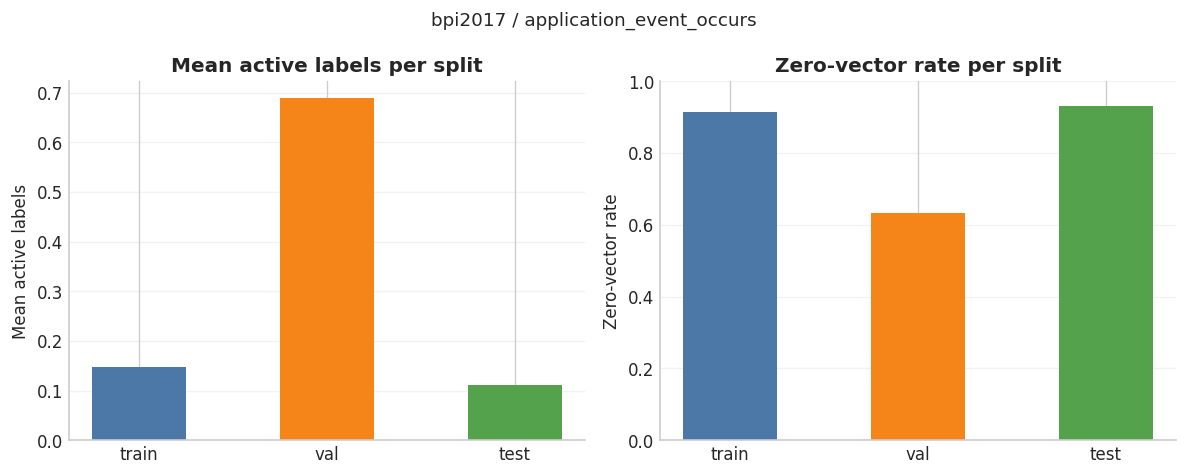

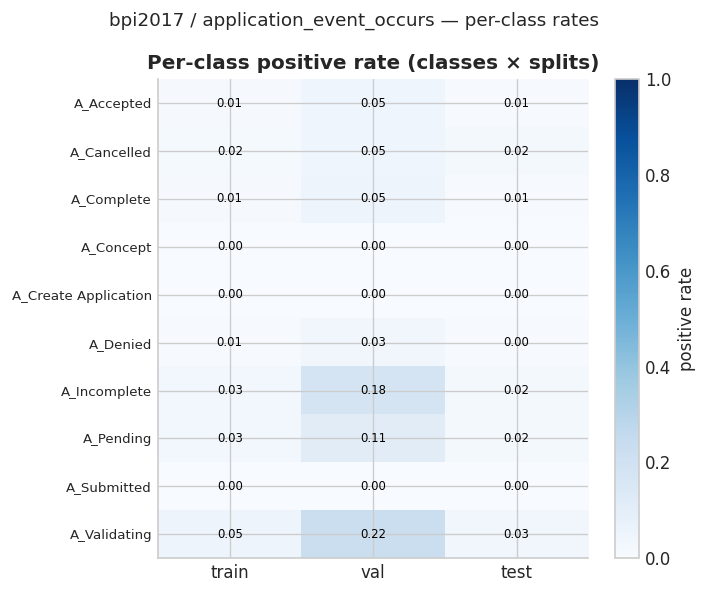

  4%|▎         | 1/27 [00:22<09:37, 22.23s/it]

---
### `bpi2017` / `application_complete_within_7d`  •  `BINARY_CLASSIFICATION`  •  `timedelta=7 days 00:00:00`

,negatives,rows,positives,std,positive_rate
train,393259.0,430133.0,36874.0,0.2800,0.0857
val,3468.0,5471.0,2003.0,0.4818,0.3661
test,38868.0,41734.0,2866.0,0.2529,0.0687


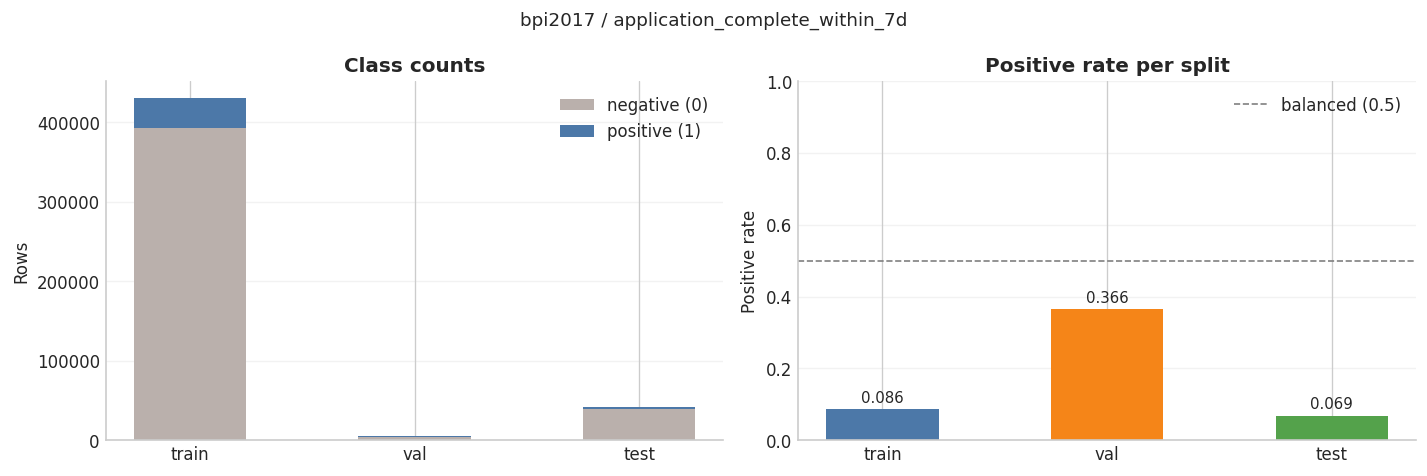

  7%|▋         | 2/27 [00:22<03:53,  9.35s/it]

---
### `bpi2017` / `application_future_event_count`  •  `REGRESSION`  •  `timedelta=7 days 00:00:00`

,min,max,p25,median,zero_rate,p95,p75,rows,mean,n_unique,std
train,0.0,11.0,0.0,0.0,0.9143,1.0,0.0,430133.0,0.1670,12.0,0.6424
val,0.0,9.0,0.0,0.0,0.6339,4.0,2.0,5471.0,0.8148,10.0,1.3148
test,0.0,11.0,0.0,0.0,0.9313,1.0,0.0,41734.0,0.1256,11.0,0.5556


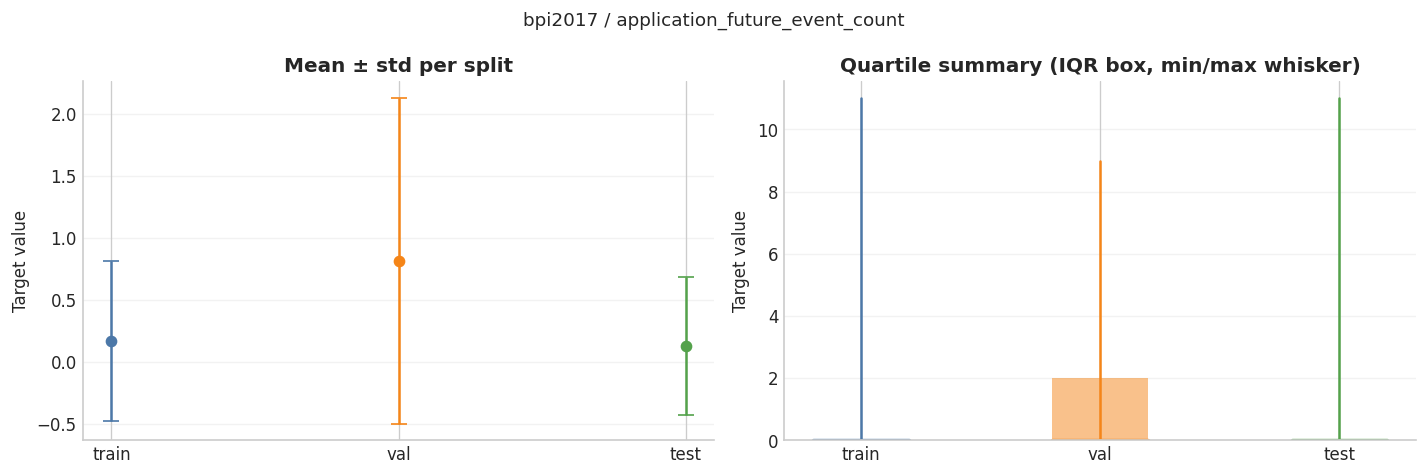

 11%|█         | 3/27 [00:22<02:05,  5.23s/it]

---
### `bpi2017` / `application_completed_within_14d`  •  `BINARY_CLASSIFICATION`  •  `timedelta=14 days 00:00:00`

,negatives,rows,positives,std,positive_rate
train,198455.0,209189.0,10734.0,0.2206,0.0513
val,3059.0,3348.0,289.0,0.2809,0.0863
test,24142.0,25459.0,1317.0,0.2215,0.0517


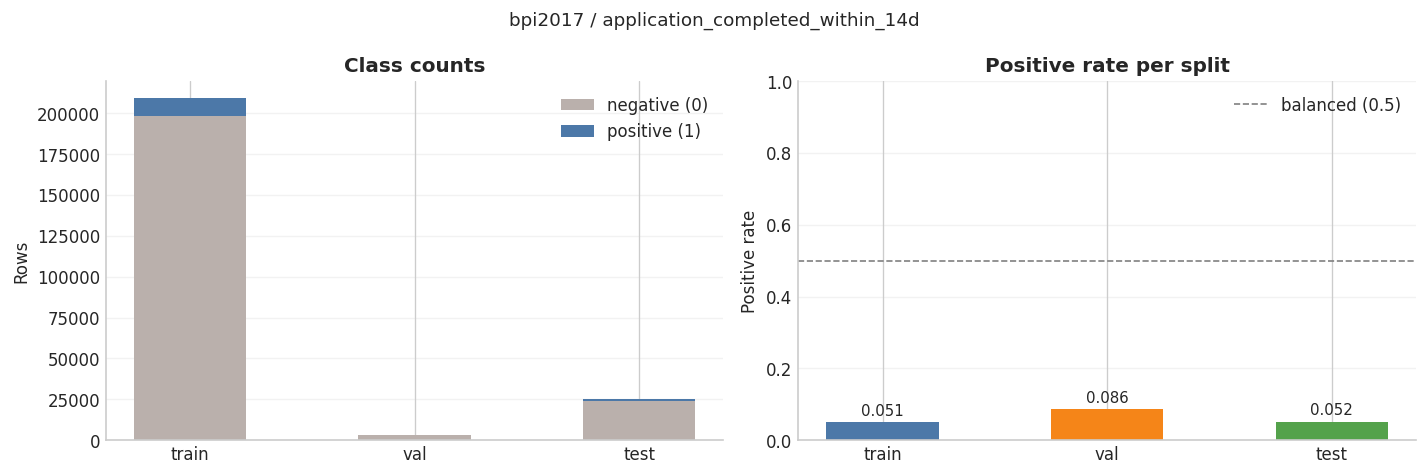

 15%|█▍        | 4/27 [00:23<01:15,  3.30s/it]

---
### `bpi2017` / `offer_event_occurs`  •  `MULTILABEL_CLASSIFICATION`  •  `timedelta=14 days 00:00:00`

,rate_O_Accepted,fully_active_rate,rate_O_Created,rate_O_Create Offer,n_labels,rows,rate_O_Returned,zero_vector_rate,std_active,rate_O_Sent (online only),rate_O_Refused,rate_O_Cancelled,rate_O_Sent (mail and online),mean_active
train,0.0339,0.0,0.0,0.0,8.0,282534.0,0.0358,0.9057,0.3979,0.0000,0.0090,0.0416,0.0002,0.1205
val,0.1143,0.0,0.0,0.0,8.0,4058.0,0.1516,0.7393,0.6390,0.0005,0.0404,0.0439,0.0002,0.3509
test,0.0205,0.0,0.0,0.0,8.0,30709.0,0.0212,0.9233,0.3373,0.0000,0.0060,0.0440,0.0001,0.0918


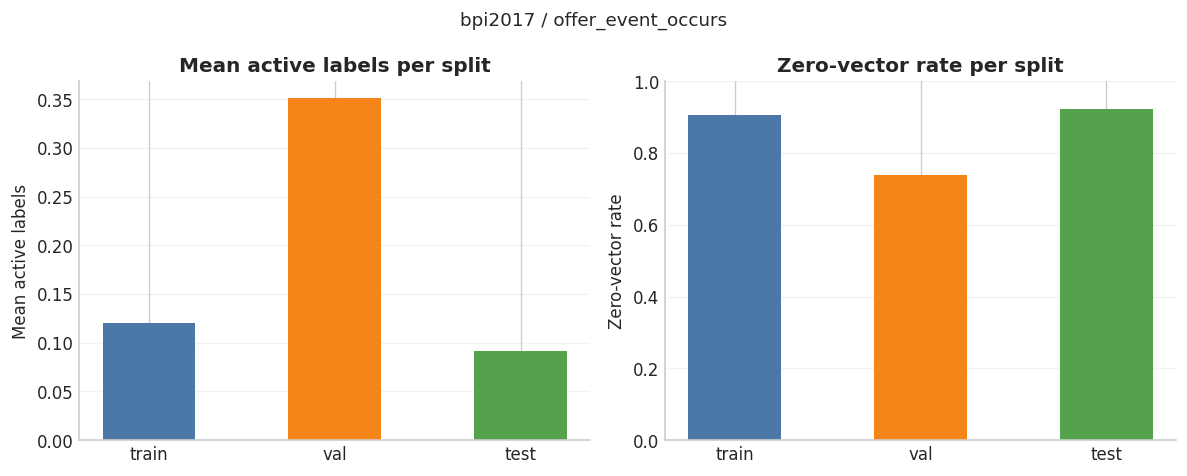

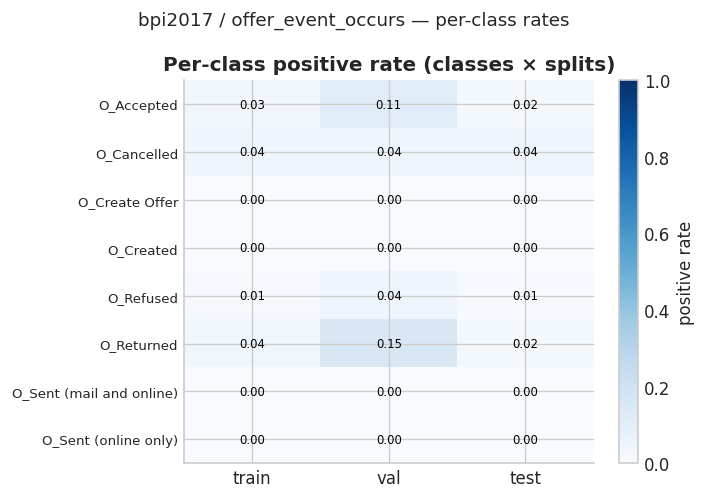

 19%|█▊        | 5/27 [00:35<02:20,  6.36s/it]

---
### `bpi2017` / `offer_cancelled_within_14d`  •  `BINARY_CLASSIFICATION`  •  `timedelta=14 days 00:00:00`

,negatives,rows,positives,std,positive_rate
train,270791.0,282534.0,11743.0,0.1996,0.0416
val,3880.0,4058.0,178.0,0.2048,0.0439
test,29359.0,30709.0,1350.0,0.2050,0.0440


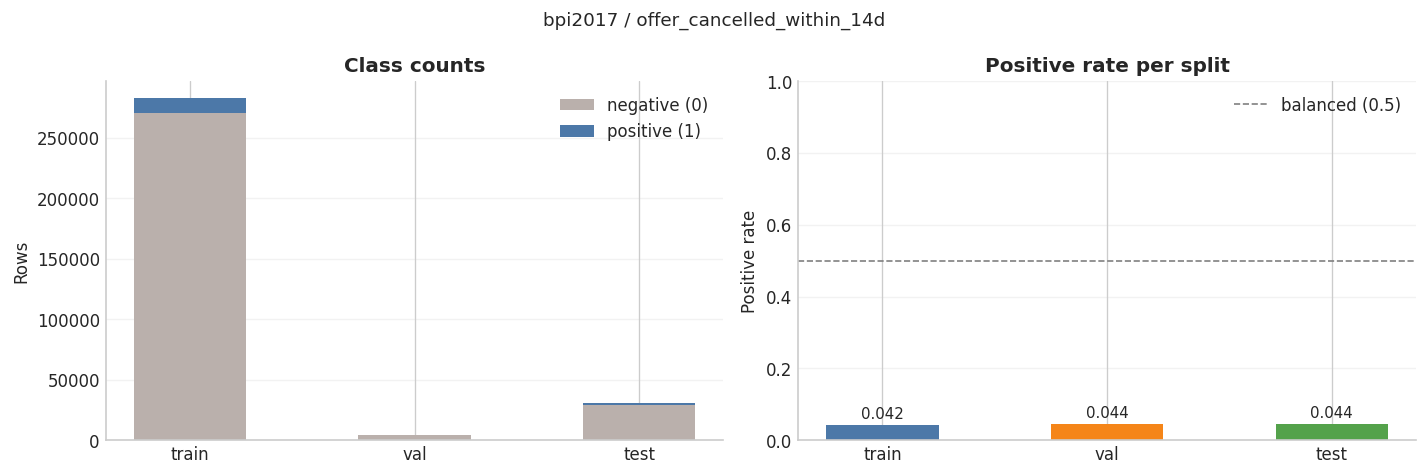

 22%|██▏       | 6/27 [00:35<01:30,  4.31s/it]

---
### `bpi2017` / `application_offer_event_count`  •  `REGRESSION`  •  `timedelta=7 days 00:00:00`

,min,max,p25,median,zero_rate,p95,p75,rows,mean,n_unique,std
train,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0
val,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0
test,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0


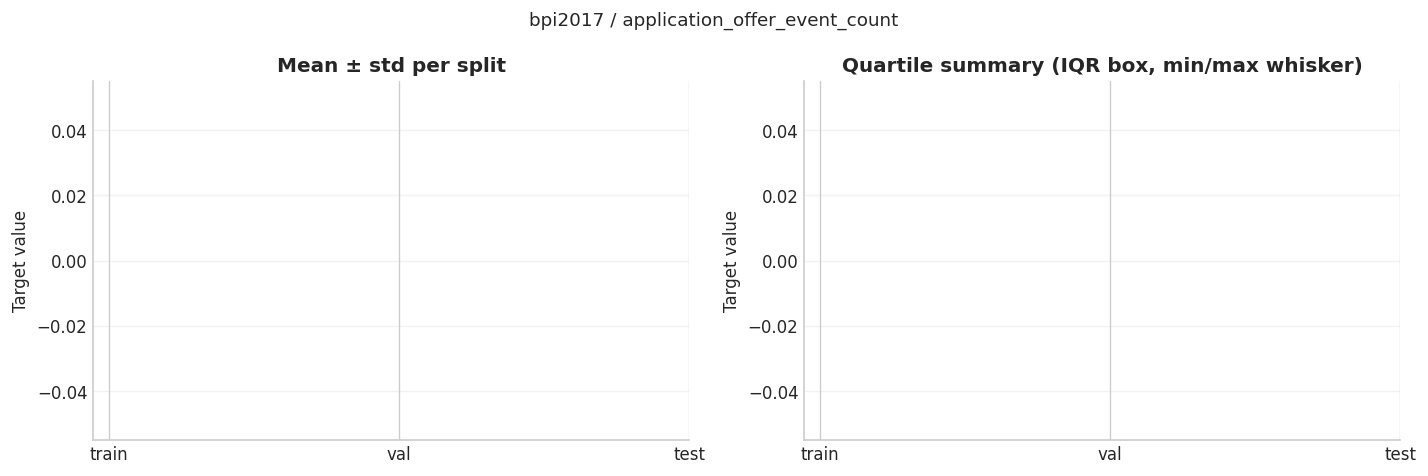

 26%|██▌       | 7/27 [00:35<00:59,  3.00s/it]

---
### `bpi2019` / `po_item_event_occurs`  •  `MULTILABEL_CLASSIFICATION`  •  `timedelta=14 days 00:00:00`

,rate_Change Quantity,rate_SRM: Held,rate_Block Purchase Order Item,rate_Cancel Goods Receipt,n_labels,rate_SRM: Change was Transmitted,std_active,rate_Create Purchase Requisition Item,rate_Change payment term,rate_Delete Purchase Order Item,...,rate_Record Goods Receipt,rate_Record Service Entry Sheet,rate_SRM: Deleted,rows,rate_Record Subsequent Invoice,rate_Cancel Subsequent Invoice,rate_Change Approval for Purchase Order,rate_SRM: Awaiting Approval,rate_Vendor creates invoice,rate_SRM: Transfer Failed (E.Sys.)
train,0.0048,0.0,0.0002,0.0007,42.0,0.0,0.7233,0.0000,0.0,0.0013,...,0.0645,0.0014,0.0001,1801430.0,0.0001,0.0002,0.0009,0.0001,0.0540,0.0
val,0.0103,0.0,0.0001,0.0017,42.0,0.0,1.0285,0.0000,0.0,0.0019,...,0.1653,0.0049,0.0001,25623.0,0.0001,0.0009,0.0016,0.0001,0.1507,0.0
test,0.0043,0.0,0.0001,0.0005,42.0,0.0,0.6196,0.0001,0.0,0.0011,...,0.0306,0.0021,0.0001,354378.0,0.0001,0.0003,0.0005,0.0001,0.0244,0.0


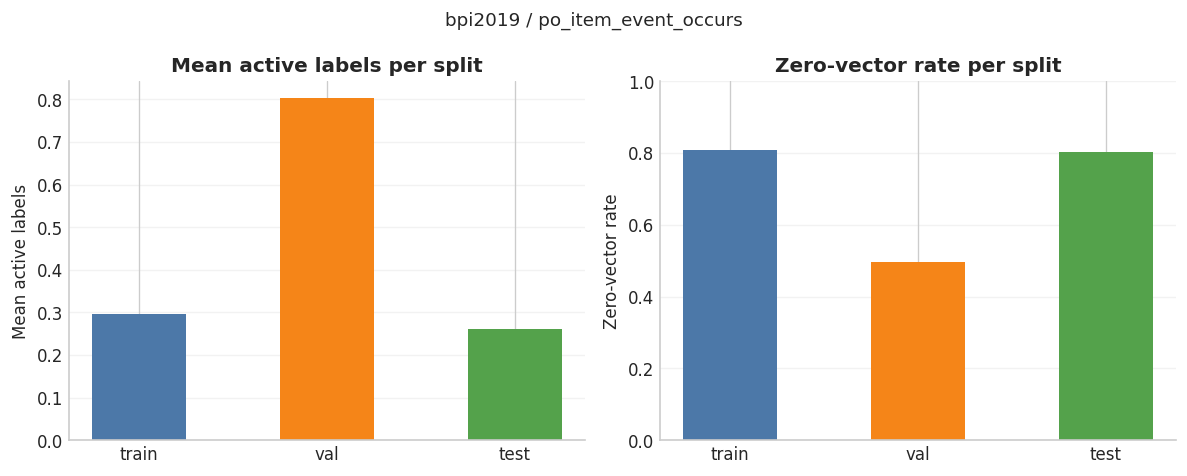

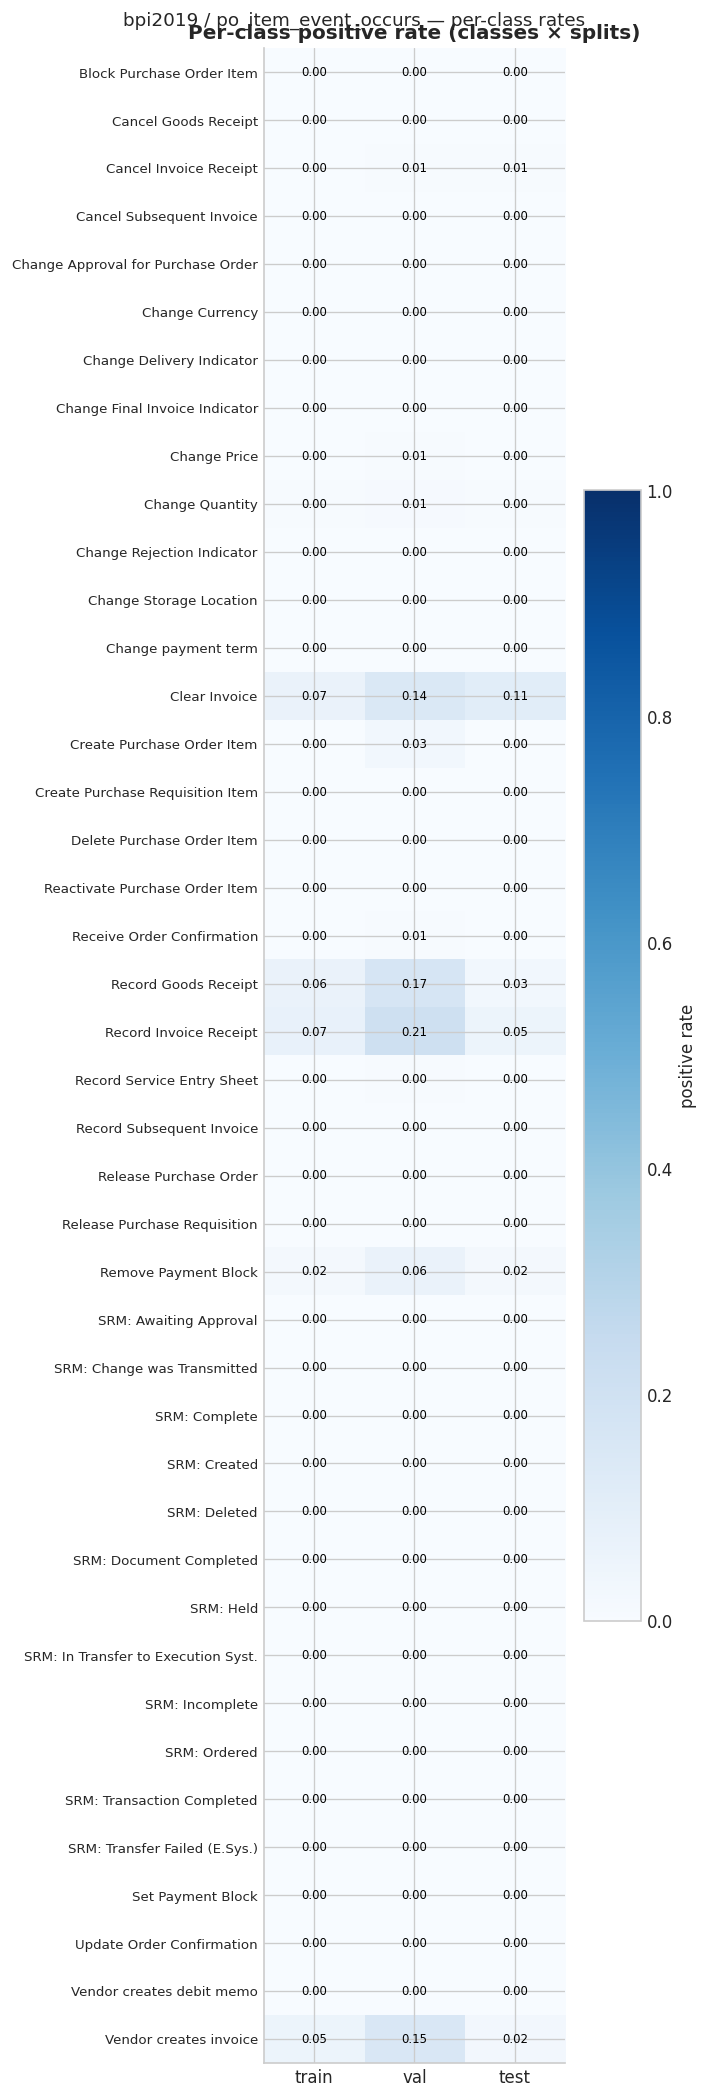

 30%|██▉       | 8/27 [04:42<25:30, 80.56s/it]

---
### `bpi2019` / `po_item_complete_within_14d`  •  `BINARY_CLASSIFICATION`  •  `timedelta=14 days 00:00:00`

,negatives,rows,positives,std,positive_rate
train,1455630.0,1801430.0,345800.0,0.3938,0.1920
val,12756.0,25623.0,12867.0,0.5000,0.5022
test,284464.0,354378.0,69914.0,0.3980,0.1973


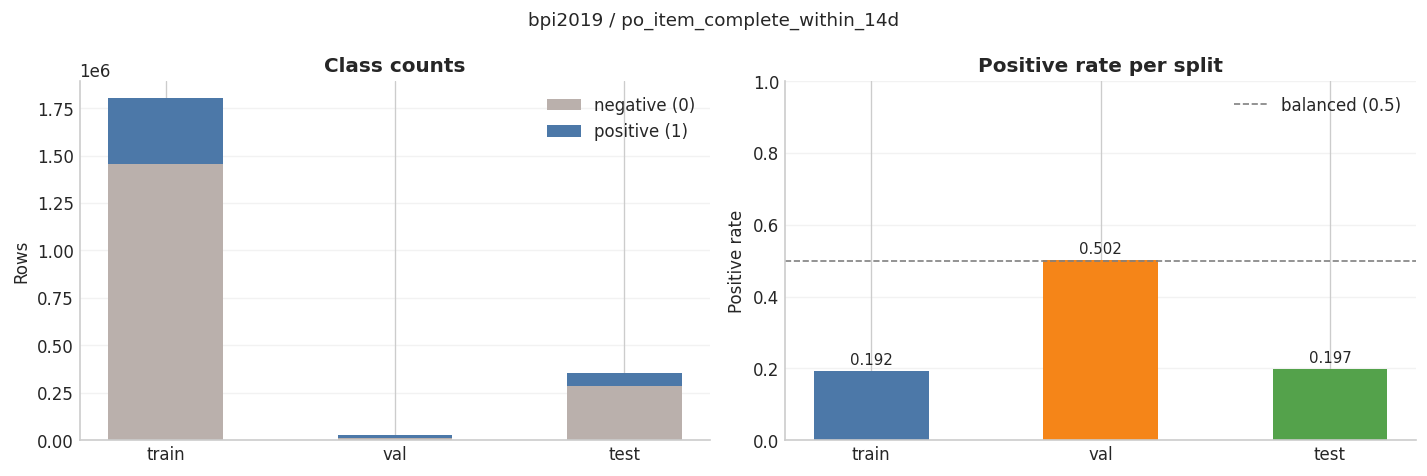

 33%|███▎      | 9/27 [04:42<16:39, 55.51s/it]

---
### `bpi2019` / `po_item_future_event_count`  •  `REGRESSION`  •  `timedelta=14 days 00:00:00`

,min,max,p25,median,zero_rate,p95,p75,rows,mean,n_unique,std
train,0.0,160.0,0.0,0.0,0.8080,2.0,0.0,1801430.0,0.3135,81.0,0.9697
val,0.0,72.0,0.0,1.0,0.4978,3.0,1.0,25623.0,0.8564,32.0,1.5420
test,0.0,170.0,0.0,0.0,0.8027,1.0,0.0,354378.0,0.2794,51.0,0.9847


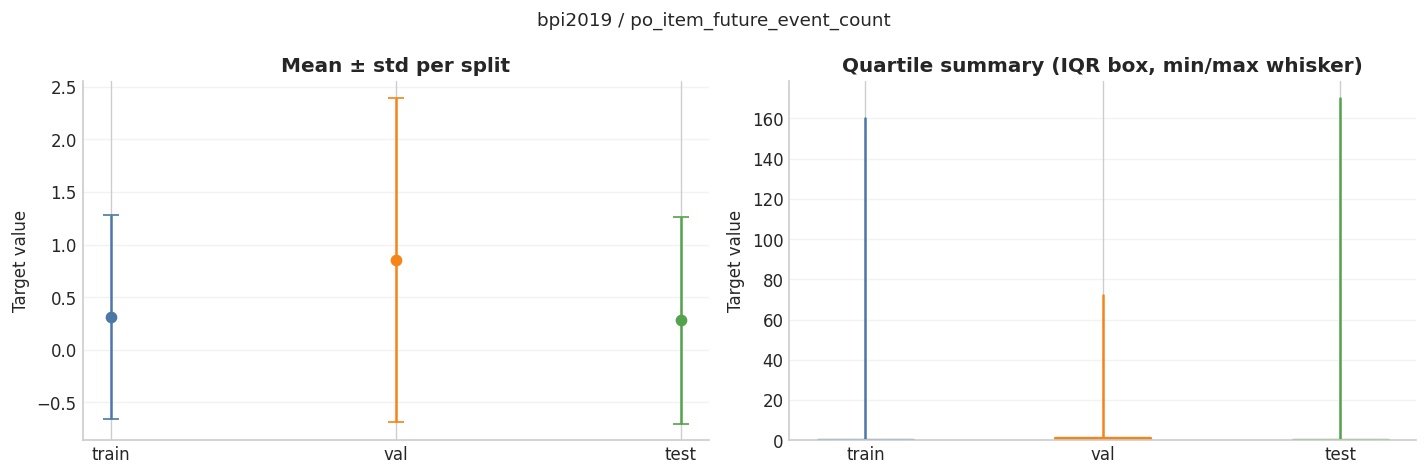

 37%|███▋      | 10/27 [04:43<10:54, 38.53s/it]

---
### `bpi2019` / `po_item_clear_invoice_within_14d`  •  `BINARY_CLASSIFICATION`  •  `timedelta=14 days 00:00:00`

,negatives,rows,positives,std,positive_rate
train,1684353.0,1801430.0,117077.0,0.2465,0.0650
val,21970.0,25623.0,3653.0,0.3496,0.1426
test,315633.0,354378.0,38745.0,0.3121,0.1093


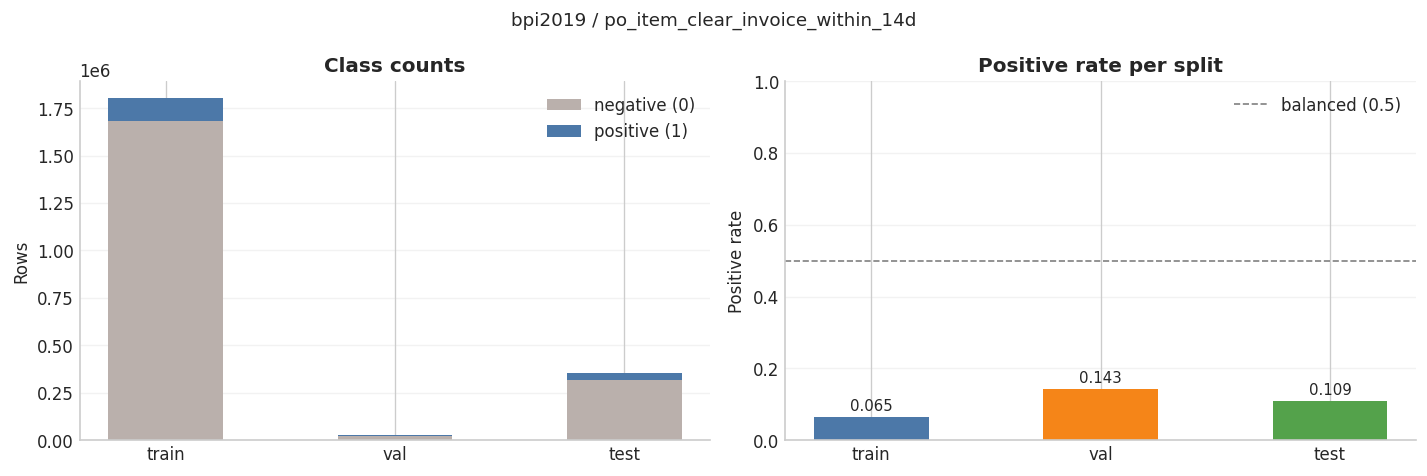

 41%|████      | 11/27 [04:43<07:09, 26.86s/it]

---
### `bpi2019` / `po_item_future_goods_receipt_count`  •  `REGRESSION`  •  `timedelta=14 days 00:00:00`

,min,max,p25,median,zero_rate,p95,p75,rows,mean,n_unique,std
train,0.0,113.0,0.0,0.0,0.9355,1.0,0.0,1801430.0,0.0717,48.0,0.4188
val,0.0,33.0,0.0,0.0,0.8347,1.0,0.0,25623.0,0.1880,18.0,0.7016
test,0.0,100.0,0.0,0.0,0.9694,0.0,0.0,354378.0,0.0369,30.0,0.4017


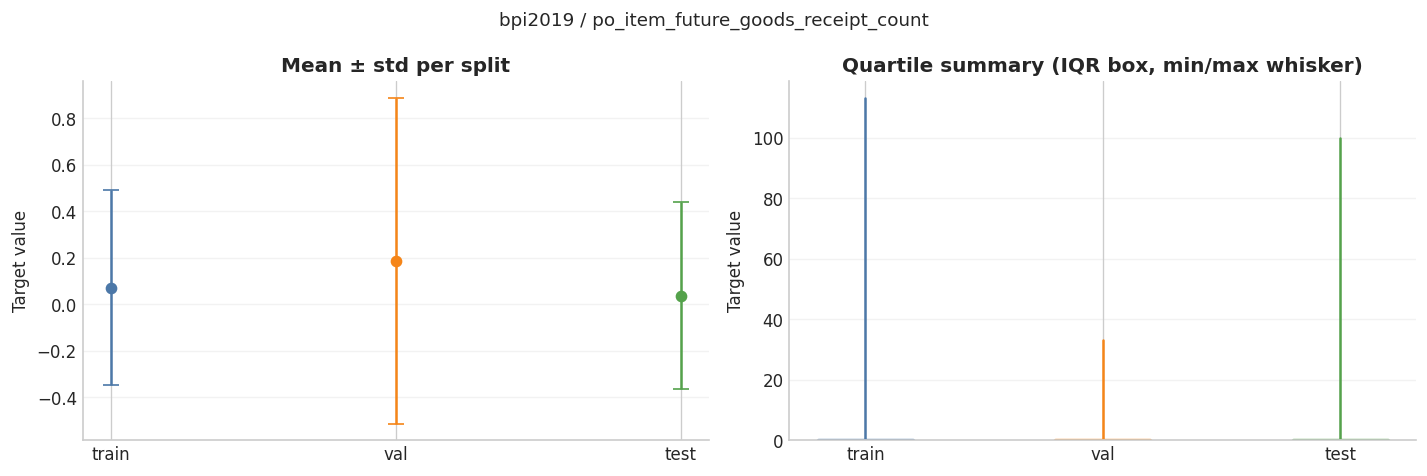

 44%|████▍     | 12/27 [04:44<04:42, 18.83s/it]

---
### `bpi2019` / `po_item_vendor_clear_invoice_14d`  •  `BINARY_CLASSIFICATION`  •  `timedelta=14 days 00:00:00`

Making task table for train split from scratch...
Loading Database object from /workspace/.cache/bpi2019/db...
Done in 10.56 seconds.


In [ ]:
from tqdm import tqdm

# Accumulate scalar summaries for CSV output at the end
all_records: list[dict] = []
]

for ds, task_name, cls in tqdm(TASK_SPECS):
    task_type = cls.task_type
    label_names = MULTILABEL_LABELS.get(task_name)

    display(Markdown(
        f"---\n### `{ds}` / `{task_name}`"
        f"  •  `{task_type.name}`"
        f"  •  `timedelta={cls.timedelta}`"
    ))

    task = get_task(ds, task_name, download=False)

    split_stats: dict[str, dict] = {}
    for split in SPLITS:
        df = task.get_table(split, mask_input_cols=False).df

        if task_type == TaskType.MULTILABEL_CLASSIFICATION:
            stats = _stats_multilabel(df, label_names)
        elif task_type == TaskType.BINARY_CLASSIFICATION:
            stats = _stats_binary(df)
        elif task_type == TaskType.MULTICLASS_CLASSIFICATION:
            stats = _stats_multiclass(df)
        else:
            stats = _stats_regression(df)

        split_stats[split] = stats
        del df  # release immediately

    # Build summary table (shared columns only)
    shared_cols = set.intersection(*(set(v.keys()) for v in split_stats.values()))
    summary_df = pd.DataFrame(
        {split: {k: split_stats[split][k] for k in shared_cols} for split in SPLITS}
    ).T
    display(summary_df)

    # Plot
    if task_type == TaskType.BINARY_CLASSIFICATION:
        _plot_binary(split_stats, title=f"{ds} / {task_name}")
    elif task_type == TaskType.MULTILABEL_CLASSIFICATION:
        _plot_multilabel_bars(split_stats, title=f"{ds} / {task_name}")
        _plot_multilabel_heatmap(split_stats, label_names, title=f"{ds} / {task_name} — per-class rates")
    elif task_type == TaskType.MULTICLASS_CLASSIFICATION:
        _plot_multiclass(split_stats, title=f"{ds} / {task_name}")
    else:
        _plot_regression(split_stats, title=f"{ds} / {task_name}")

    # Accumulate flat record for CSV summary
    for split in SPLITS:
        rec = {"dataset": ds, "task": task_name, "task_type": task_type.name,
               "timedelta": str(cls.timedelta), "split": split}
        rec.update(split_stats[split])
        all_records.append(rec)

    # Release task and run gc to avoid accumulation across iterations
    del task, split_stats, summary_df
    gc.collect()

print("Done.")

---
## CSV summaries — one per task type

Each cell below filters `all_records` to one task type and prints the CSV so it can be copied out or saved.

In [ ]:
display(Markdown("### Binary classification — CSV"))

binary_cols = ["dataset", "task", "timedelta", "split", "rows",
               "positives", "negatives", "positive_rate", "std"]

binary_df = pd.DataFrame(
    [r for r in all_records if r["task_type"] == TaskType.BINARY_CLASSIFICATION.name]
)[[c for c in binary_cols if c in pd.DataFrame(all_records).columns]]

print(binary_df.to_csv(index=False))

In [ ]:
display(Markdown("### Multilabel classification — CSV"))

multilabel_core = ["dataset", "task", "timedelta", "split", "rows", "n_labels",
                   "mean_active", "std_active", "zero_vector_rate", "fully_active_rate"]

ml_records = [r for r in all_records if r["task_type"] == TaskType.MULTILABEL_CLASSIFICATION.name]
if ml_records:
    ml_df = pd.DataFrame(ml_records)
    # Core columns first, then per-class rate_ columns
    rate_cols = sorted([c for c in ml_df.columns if c.startswith("rate_")])
    ordered_cols = [c for c in multilabel_core if c in ml_df.columns] + rate_cols
    print(ml_df[ordered_cols].to_csv(index=False))
else:
    print("No multilabel tasks found.")

In [ ]:
display(Markdown("### Multiclass classification — CSV"))

multiclass_cols = ["dataset", "task", "timedelta", "split", "rows",
                   "n_classes_present", "majority_class", "majority_count",
                   "minority_class", "minority_count", "imbalance_ratio"]

mc_records = [r for r in all_records if r["task_type"] == TaskType.MULTICLASS_CLASSIFICATION.name]
if mc_records:
    mc_df = pd.DataFrame(mc_records)
    print(mc_df[[c for c in multiclass_cols if c in mc_df.columns]].to_csv(index=False))
else:
    print("No multiclass tasks found.")

In [ ]:
display(Markdown("### Regression — CSV"))

regression_cols = ["dataset", "task", "timedelta", "split", "rows",
                   "mean", "std", "min", "p25", "median", "p75", "p95", "max",
                   "zero_rate", "n_unique"]

reg_records = [r for r in all_records if r["task_type"] == TaskType.REGRESSION.name]
if reg_records:
    reg_df = pd.DataFrame(reg_records)
    print(reg_df[[c for c in regression_cols if c in reg_df.columns]].to_csv(index=False))
else:
    print("No regression tasks found.")